In [375]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library(limma)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

circlize version 0.4.17
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




In [335]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 6292
# final number of annotated genes: 6016

[1] 6016

[1] 6292

In [365]:
mcolors <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
mcolors<- c(mcolors, "grey")
names(mcolors) <- c('canonical', 'downstream', 'antisense', 'Not sig')
mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "not sig")

mcol <- c("#80b1d3", "#fb8072", "grey")
names(mcol) <- c("Down in MUT", "Up in MUT", "Not sig")

In [337]:
nascent_all<- '../data/rna/nascentRNA/isoquant/250925_nRNA_tx_alignment_isoform_counts.tsv'
count_all<- read.table(nascent_all, header = TRUE, sep = "\t")

count_all<- count_all %>% 
    mutate(iso_id = str_split_i(isoform, ":", 1)) %>% 
    mutate(gene_id = str_split_i(iso_id, "_", 1)) %>%
    mutate(feature_id = str_split_i(isoform, ":", 2)) %>% 
    mutate(iso = paste0(isoform, "_", gene_id)) %>%
    select(iso, ys18_rep1, ys18_rep2, ym209_rep1, ym209_rep2) %>% 
    arrange(iso) %>% 
    column_to_rownames(var= "iso")

colnames(count_all)<- c("WT rep1", "WT rep2", "MUT rep1", "MUT rep2")
tpm_all<- countToTPM(count_all, normalize_by_len = FALSE)

write.table(x = count_all, file = '../data/7_nascent_rna_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm_all, file = '../data/7_nascent_rna_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

## TSS count table

In [338]:
nascent_tx<- '../data/rna/nascentRNA/isoquant/250920_nRNA_tx_alignment_annot_by_tss_isoform_counts.tsv'
count<- read.table(nascent_tx, header = TRUE, sep = "\t")

# reformat to same output with flair
count<- count %>% 
    mutate(iso_id = str_split_i(isoform, ":", 1)) %>% 
    mutate(gene_id = str_split_i(iso_id, "_", 1)) %>%
    mutate(iso = paste0(isoform, "_", gene_id)) %>% 
    select(iso, ys18_rep1, ys18_rep2, ym209_rep1, ym209_rep2) %>% 
    arrange(iso) %>% 
    column_to_rownames(var= "iso")

colnames(count)<- c("WT rep1", "WT rep2", "MUT rep1", "MUT rep2")
RPK = count_all/1000
sc_factor = colSums(RPK)/ 1e6
tpm<- countToTPM(count, normalize_by_len = FALSE, scaling_factor = sc_factor)

write.table(x = count, file = '../data/7_nascent_rna_tss_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm, file = '../data/7_nascent_rna_tss_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

## Differential gene expression with limma

.
FALSE  TRUE 
 9224  8181 

[1] "number of genes : 5293"

[1] "number of isoforms: 8181"

,groupMUT,groupWT
AAC1:canonical_AAC1,1.984168,3.0294549
AAC1:downstream_AAC1,3.068419,3.2432702
AAC3:canonical_AAC3,6.581151,6.7431518
AAD14:canonical_AAD14,5.169818,4.6241189
AAD14:downstream_AAD14,4.664387,2.4108863
AAD16:downstream_AAD16,3.978688,-0.7707201


,groupMUT - groupWT
groupMUT,1
groupWT,-1


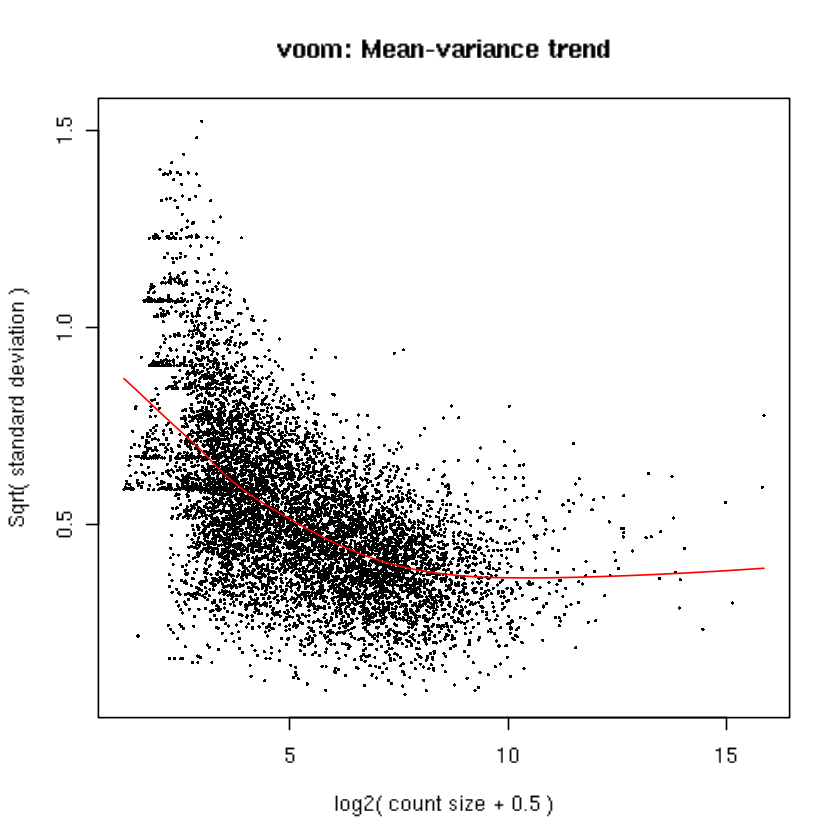

In [353]:
count<- read.table('../data/7_nascent_rna_tss_count.tsv', header = T, row.names = 1, sep = '\t')
tpm<- read.table('../data/7_nascent_rna_tss_tpm.tsv', header = T, row.names = 1, sep = '\t')

smallestGroupSize = 2
smallestCount = 10
keep <- rowSums(count >= smallestCount) >= smallestGroupSize
keep %>% table()
count<- count[keep, ]
tpm<-tpm[keep,]
n_genes<- length(str_split_i(rownames(tpm), ":", 1) %>% sort() %>% unique())
paste0("number of genes : ", n_genes) 
paste0("number of isoforms: ", dim(tpm)[1])


group<- c("WT", "WT", "MUT", "MUT")
mm <- model.matrix(~0 + group)
y <- voom(count, mm, plot = T)

fit <- lmFit(y, mm)
head(coef(fit))

contr <- makeContrasts(groupMUT - groupWT, levels = colnames(coef(fit)))
contr

tmp <- contrasts.fit(fit, contr)
tmp <- eBayes(tmp)

topTable <- topTable(tmp, sort.by = "P", n = Inf)

de_df<- cbind(WT = rowMeans(tpm[, c(1:2)]), MUT = rowMeans(tpm[,c(3,4)])) %>% as.data.frame()
de_df$log2FoldChange = topTable[match(rownames(de_df), rownames(topTable)), "logFC"]
de_df$padj = topTable[match(rownames(de_df), rownames(topTable)), "adj.P.Val"]

de_df = analyzeDESeq_nascent(res_df =  de_df, final_iso_tb$gene_id, padj_cutoff = 0.05, log2fc_cutoff = 0.5, annot_down = 3, annot_up = 3)

de_df$class= final_iso_tb[match(de_df$gene_id, final_iso_tb$gene_id), "class"]
de_df$class<- factor(de_df$class, levels = c('low', 'medium', 'high'))
de_df$feature_id<- factor(de_df$feature_id, levels = c('canonical', 'downstream', 'antisense'))

write.table(x = de_df, file = '../data/7_nascent_rna_DE_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)

In [354]:
mcolors <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
mcolors<- c(mcolors, "grey")
names(mcolors) <- c('canonical', 'downstream', 'antisense', 'Not sig')

de_df$type = as.character(de_df$feature_id)
de_df[de_df$labels == 'Not sig', 'type'] = 'Not sig'
de_df$type<- factor(de_df$type, levels = c('canonical', 'downstream', 'antisense', 'Not sig'))
de_df[de_df$padj<10e-15, 'padj'] = 10e-15

Warning message:
“Removed 7736 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 7736 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


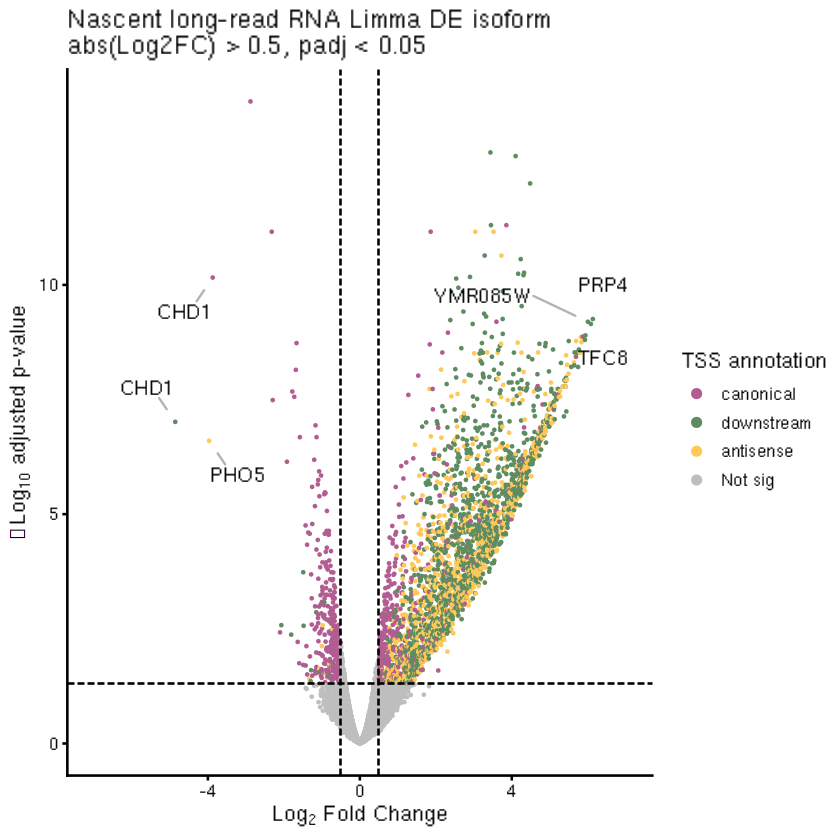

In [355]:
p <- de_df %>%
    ggplot(aes(x = log2FoldChange, y = -log10(padj), label = annotation)) +
    geom_point(aes(color = type), size = 0.2) +
    geom_text_repel(box.padding = 1, point.padding = 1, max.overlaps = 5, size = 4, segment.color = "grey70") +
    labs(x = expression(Log[2] * " Fold Change"), y = expression(-Log[10] * " adjusted p-value"), 
       title = "Nascent long-read RNA Limma DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", color = "TSS annotation")  +
    geom_hline(yintercept = -log10(0.05), color = 'black', linetype = "longdash") +
    geom_vline(xintercept = 0.5, color = 'black', linetype = "longdash") +
    geom_vline(xintercept = -0.5, color = 'black', linetype = "longdash") +
    scale_color_manual(values = mcolors) +
    guides(color = guide_legend(override.aes = list(size = 2))) +
    xlim(-7, 7)
p
ggsave('../figures/Supp_nascent_rna_isoform_DE_volcano.pdf', width = 5, height = 3)

In [356]:
df1<- de_df %>%
    count(class, labels, name = 'total_per_label') %>% left_join(count(de_df, class, name = 'total'))

df2<- de_df %>%
    count(labels, feature_id, class) %>% 
    left_join(df1, by = join_by(labels, class)) %>% 
    mutate(p_per_label = n/total_per_label, p = n/total)

iso_levels <- df2 %>%
    filter(labels != "Not sig", class == "low") %>% 
    select(feature_id, labels, p) %>% 
    pivot_wider(names_from = labels, values_from = p) %>% 
    mutate(delta = `Up in MUT` - `Down in MUT`) %>% arrange(-delta) %>% 
    pull(feature_id)

write.table(df2 %>% select(class, feature_id, labels, n, total_per_label, total, p_per_label, p),
          '../data/7_nascent_rna_DE_fraction_by_expr.tsv', quote = F, sep = '\t', col.names = T, row.names = F)

Joining with `by = join_by(class)`


In [364]:
mcolors

canonical  downstream   antisense     Not sig 
"#B25D91FF" "#5E8C61FF" "#FFC857FF"      "grey"

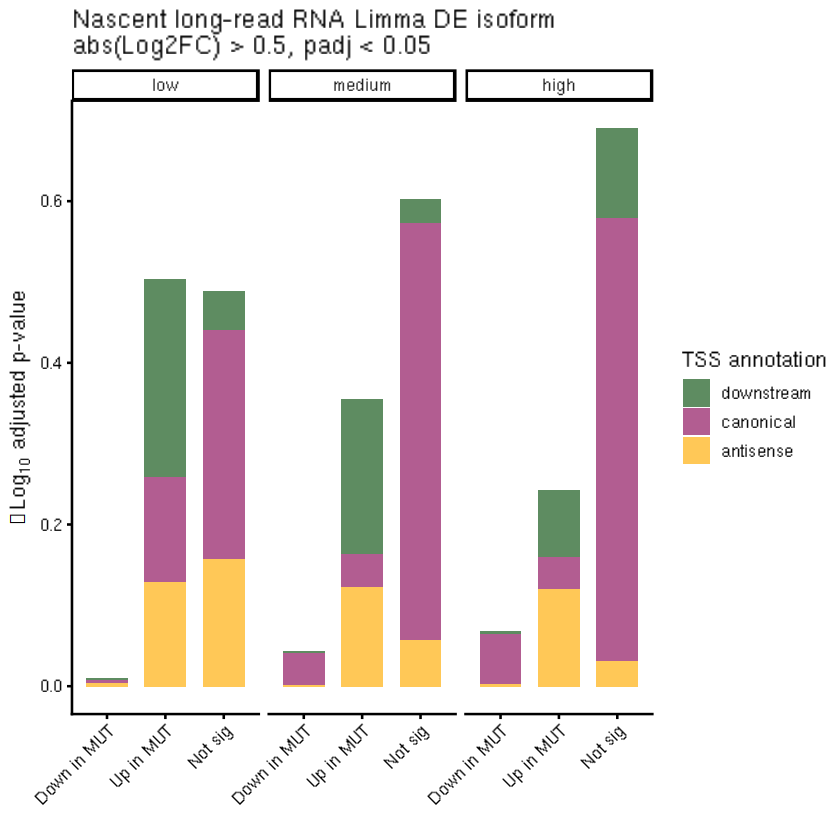

In [366]:
p1<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Nascent long-read RNA Limma DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "TSS annotation")  +
    facet_wrap(vars(class), ncol = 3)
p1
ggsave("../figures/Supp_nascent_rna_percentage_of_isoform_by_expr_with_sig.pdf", p1, width = 6, height = 5)

p2<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    filter(labels != "Not sig") %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Nascent long-read RNA Limma DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "TSS annotation") +
    facet_wrap(vars(class), ncol = 3) 

ggsave("../figures/Supp_nascent_rna_percentage_of_isoform_by_expr.pdf", p2, width = 5, height = 5)

In [358]:
expr_c = unique(de_df$class)
iso_c = unique(de_df$feature_id)
de_c =  unique(de_df$labels)

for (expr in expr_c){
    for (iso in iso_c){
        for (de in de_c){
            genelist = de_df %>% filter(class == expr, feature_id == iso, labels == de) %>% pull(gene_id) %>% sort() %>% unique()
            prefix = paste0(str_replace_all(expr, " ", "_"), "_", iso, "_", str_replace_all(de, " ", "_"))
            message(prefix)
            message(length(genelist))
            write.table(genelist, paste0("../data/7_nascent_rna_", prefix, ".tsv"), 
                        sep = "\t", quote = F, col.names = F, row.names = F)}
    }
}

medium_downstream_Down_in_MUT

6

medium_downstream_Not_sig

141

medium_downstream_Up_in_MUT

985

medium_antisense_Down_in_MUT

6

medium_antisense_Not_sig

293

medium_antisense_Up_in_MUT

629

medium_canonical_Down_in_MUT

210

medium_canonical_Not_sig

2660

medium_canonical_Up_in_MUT

213

high_downstream_Down_in_MUT

5

high_downstream_Not_sig

167

high_downstream_Up_in_MUT

124

high_antisense_Down_in_MUT

3

high_antisense_Not_sig

46

high_antisense_Up_in_MUT

182

high_canonical_Down_in_MUT

95

high_canonical_Not_sig

833

high_canonical_Up_in_MUT

62

low_downstream_Down_in_MUT

1

low_downstream_Not_sig

50

low_downstream_Up_in_MUT

263

low_antisense_Down_in_MUT

4

low_antisense_Not_sig

169

low_antisense_Up_in_MUT

139

low_canonical_Down_in_MUT

5

low_canonical_Not_sig

309

low_canonical_Up_in_MUT

142



In [362]:
genelist = de_df %>% filter(labels != "Not sig") %>% rownames() %>% sort() %>% unique()

write.table(x = genelist, file = "../data/7_nascent_rna_all_DE_isoforms.tsv", 
            sep = "\t", quote = F, col.names = F, row.names = F)

genelist = de_df %>% filter(labels != "Not sig") %>% pull(gene_id) %>% sort() %>% unique()

write.table(x = genelist, file = "../data/7_nascent_rna_all_DE_isoforms_geneid.tsv", 
            sep = "\t", quote = F, col.names = F, row.names = F)

## Combined isoform expression change and total expression change

In [373]:
gene_per_class<- de_df %>% distinct(gene_id, class) %>% count(class, name = 'total_n_gene')


labels_wide <- de_df %>%
  select(gene_id, feature_id, labels, class, log2FoldChange) %>%
  distinct(gene_id, feature_id, .keep_all = TRUE) %>%
  mutate(labels = as.character(labels)) %>%
  pivot_wider(id_cols = c(gene_id, class), names_from = feature_id,
              values_from = labels, names_prefix = "")

lfc_wide <- de_df %>%
  distinct(gene_id, feature_id, .keep_all = TRUE) %>%
  pivot_wider(id_cols = c(gene_id, class), names_from = feature_id,
              values_from = log2FoldChange, names_prefix = "lfc_")

df_joint <- left_join(labels_wide, lfc_wide, by = c("gene_id", "class"))

df_joint<- df_joint %>%
    mutate(across(any_of(c("canonical", "downstream", "antisense")), ~ replace_na(., "Not sig"))) %>% 
    mutate(
        canon_short  = recode(canonical,  "Down in MUT" = "Down", "Up in MUT" = "Up", "Not sig" = "NS"),
        down_short   = recode(downstream, "Down in MUT" = "Down", "Up in MUT" = "Up", "Not sig" = "NS"),
        anti_short   = recode(antisense,  "Down in MUT" = "Down", "Up in MUT" = "Up", "Not sig" = "NS")
    ) %>% 
    mutate(combo = paste0("C:", canon_short, " | D:", down_short, " | A:", anti_short))


# read gene expression change
gene_de<- read.table('../data/7_nascent_rna_gene_DE_results.tsv', sep = '\t')
df_joint$gene_de<- gene_de[match(df_joint$gene_id, rownames(gene_de)), 'labels']
df_joint$lfc_gene_de<- gene_de[match(df_joint$gene_id, rownames(gene_de)), 'log2FoldChange']


write.table(x = df_joint, file = "../data/7_nascent_rna_joint_isoform_DE_vs_gene_de_by_expr.tsv", sep = "\t", quote = F, col.names = T, row.names = F)

df<- df_joint %>% 
    count(class, combo) %>% left_join(gene_per_class, by = "class") %>% 
    mutate(frac = n/total_n_gene) %>% filter(combo != "C:NS | D:NS | A:NS")

write.table(x = df, file = "../data/7_nascent_rna_joint_isoform_DE_count_by_expr.tsv", sep = "\t", quote = F, col.names = T, row.names = F)

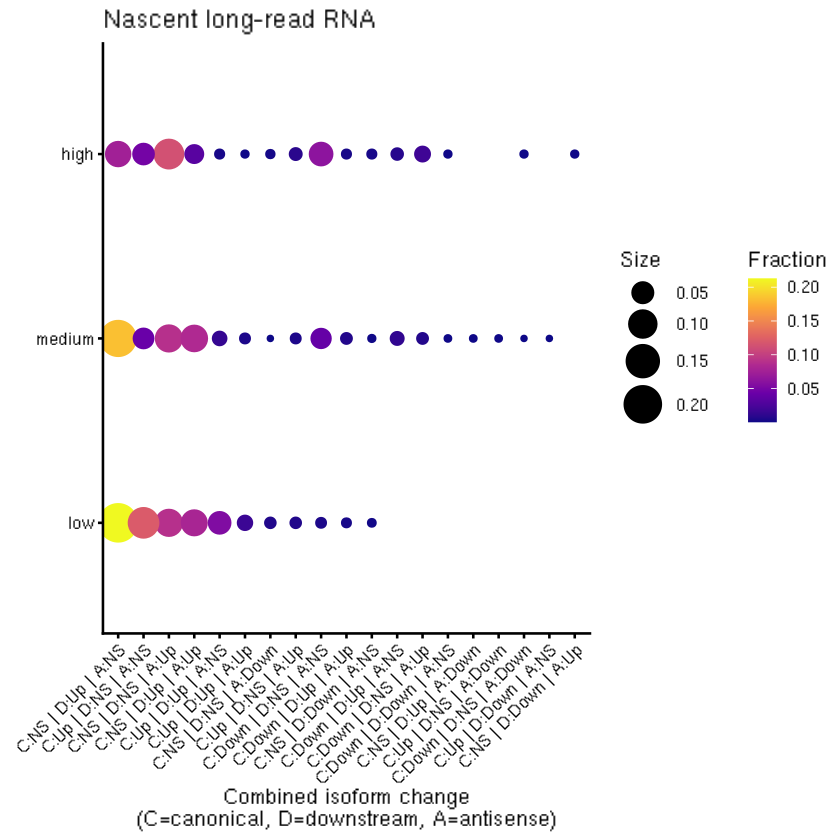

In [377]:
combo_levels = df %>% arrange(class, -frac) %>% pull(combo) %>% unique()
df$combo<- factor(df$combo, levels = combo_levels)

mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- levels(de_df$class)


p2<- ggplot(df, aes(x = combo, y = class, size = frac, color = frac)) +
    geom_point() +
    scale_size_continuous(range = c(1, 10)) +
    scale_color_viridis_c(option = "plasma") +
    labs(x ="Combined isoform change\n(C=canonical, D=downstream, A=antisense)", 
         y = "",
         title = "Nascent long-read RNA",
         size = "Fraction", color = "Fraction") +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right",
        legend.box = "horizontal"
    ) +
        guides(
        size = guide_legend(order = 1, title = "Size"),
        color = guide_colorbar(order = 2, title = "Fraction")
    )
p2
ggsave('../figures/Supp_nascent_rna_combined_isoform_DE_by_gene_expression.pdf', p2, width = 8, height = 3)

pdf 
  2

pdf 
  2

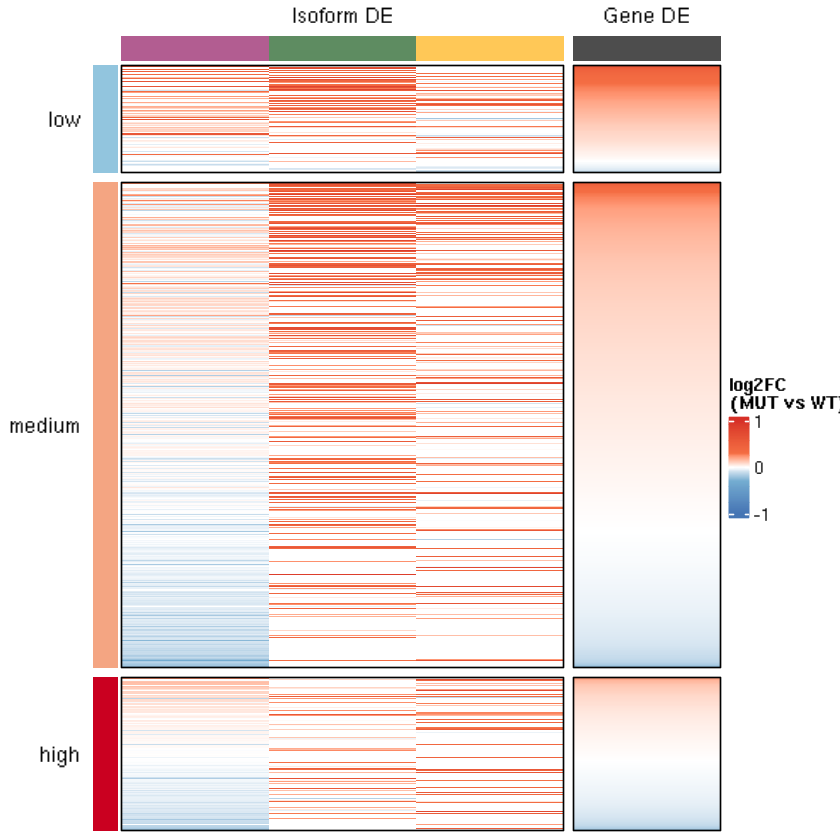

In [376]:
mat_df <- df_joint %>%
  mutate(
    class = factor(class, levels = c("low", "medium", "high"))
  ) %>%
  arrange(class) %>%
  select(gene_id, class, lfc_canonical, lfc_downstream, lfc_antisense, lfc_gene_de)

mat <- mat_df %>%
  select(lfc_canonical, lfc_downstream, lfc_antisense, lfc_gene_de) %>%
  mutate(across(everything(), ~ replace_na(., 0))) %>%
  as.matrix()

rownames(mat) <- mat_df$gene_id
colnames(mat) <- c("Canonical", "Downstream", "Antisense", "Total")

row_order_idx <- mat_df %>%
  mutate(row_idx = row_number()) %>%
  arrange(class, desc(lfc_gene_de)) %>%
  pull(row_idx)

mat    <- mat[row_order_idx, ]
mat_df <- mat_df[row_order_idx, ]

pos_max <- max(mat[mat > 0], na.rm = TRUE)
neg_min <- min(mat[mat < 0], na.rm = TRUE)

mat_scaled <- mat
mat_scaled[mat > 0] <- mat[mat > 0] / pos_max
mat_scaled[mat < 0] <- mat[mat < 0] / abs(neg_min)

lfc_cap <- 1
dir_col <- colorRamp2(
  c(-lfc_cap, -0.3, 0, 0.3, lfc_cap),
  c("#4575b4", "#74add1", "white", "#f46d43", "#d73027")
)

class_colors <- c(low = "#92c5de", medium = "#f4a582", high = "#ca0020")

mcolors <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
names(mcolors) <- c("canonical", "downstream", "antisense")

iso_colors <- c(
  "Canonical"  = mcolors[["canonical"]],
  "Downstream" = mcolors[["downstream"]],
  "Antisense"  = mcolors[["antisense"]],
  "Total"      = "grey30"
)

# ── Row = genes, Column = isoform types ──────────────────────────────────────
row_split <- mat_df$class

col_split <- factor(
  c("Isoform DE", "Isoform DE", "Isoform DE", "Gene DE"),
  levels = c("Isoform DE", "Gene DE")
)

iso_types <- factor(colnames(mat_scaled), levels = c("Canonical", "Downstream", "Antisense", "Total"))

# Left annotation: expression class
row_ha <- rowAnnotation(
  Class = mat_df$class,
  col   = list(Class = class_colors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

# Top annotation: isoform type color bar
col_ha <- HeatmapAnnotation(
  Isoform = iso_types,
  col     = list(Isoform = iso_colors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

ht <- Heatmap(
  mat_scaled,
  name                = "log2FC",
  col                 = dir_col,
  row_split           = row_split,
  column_split        = col_split,
  cluster_rows        = FALSE,
  cluster_row_slices  = FALSE,
  cluster_columns     = FALSE,
  show_row_names      = FALSE,
  show_column_names   = FALSE,
  show_heatmap_legend = FALSE,
  row_gap             = unit(2, "mm"),
  column_gap          = unit(2, "mm"),
  row_title_rot       = 0,
  row_title_gp        = gpar(fontsize = 12),
  column_title_rot    = 0,
  column_title_gp     = gpar(fontsize = 12),
  border              = TRUE,
  rect_gp             = gpar(col = "white", lwd = 0),
  left_annotation     = row_ha,
  top_annotation      = col_ha
)

lgd_class <- Legend(
  title     = "Class",
  labels    = names(class_colors),
  legend_gp = gpar(fill = class_colors)
)
lgd_lfc <- Legend(
  title     = "log2FC\n(MUT vs WT)",
  col_fun   = dir_col,
  at        = c(-lfc_cap, 0, lfc_cap),
  labels    = c(round(-lfc_cap, 1), "0", round(lfc_cap, 1)),
  direction = "vertical"
)
lgd_iso <- Legend(
  title     = "Isoform",
  labels    = names(iso_colors),
  legend_gp = gpar(fill = iso_colors)
)

pdf("../figures/Figure2E_nascent_rna_isoform_expression_DE_vs_gene_expression_DE.pdf", width = 4, height = 4)
draw(ht,
     annotation_legend_list = list(lgd_lfc),
     heatmap_legend_side = "right")
dev.off()

png("../figures/Figure2E_nascent_rna_isoform_expression_DE_vs_gene_expression_DE.png", res = 300, units = "in", width = 4, height = 4)
draw(ht,
     annotation_legend_list = list(lgd_lfc),
     heatmap_legend_side = "right")
dev.off()

draw(ht,
     annotation_legend_list = list(lgd_lfc),
     heatmap_legend_side = "right")